<a href="https://colab.research.google.com/github/RiccardoD25/Python-Programs/blob/main/Week04_RetailEdge_CLIP_GroundedSAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 04 - RetailEdge: CLIP + Grounded SAM
**Riccardo De Simini | CST 620 | Scenario audience: Priya Nair**

This notebook accepts a natural-language prompt and returns real bounding boxes and segmentation masks. It includes a completed CPU evaluation on **24 held-out synthetic images**, three categories, two prompt variants, and separate defect stress cases.

**Start:** run the cells in order. A Colab GPU is optional; CPU works too. Install/download before recording. Model weights need about 1.7 GB of downloads on the first run. Your face must remain visible during your 5-10 minute recording, and you must explain the demo in your own words.

**Results policy:** the saved CPU results below are clearly labeled. Live prompts do not overwrite them. Set `RUN_FULL_EVALUATION = True` near the end to perform a new full run. No scores are simulated.

## 1. Environment
The model API is pinned to Transformers 4.51.3. Keep Colab's working CUDA-enabled PyTorch. If running on your own machine with no PyTorch, this setup installs the CPU build. If package installation asks for a runtime restart, restart and run the cells again.

In [1]:
import sys, subprocess, importlib.metadata as meta
from packaging.version import Version
pins = {"transformers": "4.51.3", "huggingface-hub": "0.34.4", "safetensors": "0.6.2", "Pillow": "12.3.0"}
needed = []
for package, version in pins.items():
    try:
        if meta.version(package) != version: needed.append(f"{package}=={version}")
    except meta.PackageNotFoundError: needed.append(f"{package}=={version}")
for package in ["numpy", "pandas"]:
    try: meta.version(package)
    except meta.PackageNotFoundError: needed.append(package)
if needed: subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *needed])
try:
    torch_version = meta.version("torch")
except meta.PackageNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch==2.7.1", "--index-url", "https://download.pytorch.org/whl/cpu"])
    torch_version = meta.version("torch")
assert Version(torch_version.split("+")[0]) >= Version("2.6"), "Use PyTorch >= 2.6 to load the pinned CLIP checkpoint."
import torch, transformers, PIL, numpy as np, pandas as pd
print({"Python": sys.version.split()[0], "torch": torch.__version__, "transformers": transformers.__version__, "Pillow": PIL.__version__, "device": "cuda" if torch.cuda.is_available() else "cpu"})

{'Python': '3.13.15', 'torch': '2.11.0+cu130', 'transformers': '4.51.3', 'Pillow': '12.3.0', 'device': 'cuda'}


## 2. Complete implementation
This cell writes the standalone module. Expand it to inspect the detector, CLIP screen, SAM, synthetic generator, matching rules, and report creation. Ground-truth annotations are used only by evaluation, never passed to `predict()`.

Grounded SAM is the composition of Grounding DINO and SAM. CLIP adds a crop-text screen. All three checkpoints are frozen; adding a text prompt does not retrain them.

In [2]:
%%writefile retail_demo.py
"""RetailEdge: reproducible, zero-shot CLIP + Grounded SAM inspection.
Run: python retail_demo.py --evaluate --output outputs
Models are frozen. Dataset annotations never enter model inference.
"""
from __future__ import annotations
import argparse, csv, hashlib, html, json, math, os, platform, random, sys, time
from dataclasses import dataclass, asdict
from pathlib import Path
import numpy as np
from PIL import Image, ImageDraw, ImageFont, ImageFilter, ImageEnhance

MODELS = {
    'detector': ('IDEA-Research/grounding-dino-tiny', 'a2bb814dd30d776dcf7e30523b00659f4f141c71'),
    'segmenter': ('facebook/sam-vit-base', '70c1a07f894ebb5b307fd9eaaee97b9dfc16068f'),
    'clip': ('openai/clip-vit-base-patch32', '3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268'),
}
PROMPTS = {
    'cereal_box': ['cereal box', 'a cardboard box of cereal'],
    'water_bottle': ['water bottle', 'a plastic bottle of water'],
    'soda_can': ['soda can', 'an aluminum can of soda'],
}
# Fixed BEFORE test inference; no thresholds or prompts selected using test scores.
@dataclass(frozen=True)
class Config:
    seed: int = 20261003
    box_threshold: float = 0.30
    text_threshold: float = 0.25
    nms_iou: float = 0.50
    clip_min_cosine: float = 0.20
    clip_min_margin: float = 0.02
    match_iou: float = 0.50
    confident_fp_score: float = 0.50
    detector_short_edge: int = 480
    detector_long_edge: int = 800
    cpu_threads: int = 4

CONFIG = Config()
CONTROLS = ['a photo of an empty shelf', 'a photo of an unrelated background']

def dump(path, value):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(value, indent=2, allow_nan=False), encoding='utf-8')

def sha(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def font(size):
    # Pillow's bundled scalable default makes the dataset portable across OSes.
    try: return ImageFont.load_default(size=size)
    except TypeError: return ImageFont.load_default()

def sprite(category, rng, damaged=False, misaligned=False):
    """Procedural RGBA object; alpha is the exact synthetic foreground mask."""
    im = Image.new('RGBA', (190, 280)); d = ImageDraw.Draw(im)
    if category == 'cereal_box':
        col = rng.choice([(234,164,44), (224,68,52), (44,128,170)])
        front = [(15,30),(140,30),(140,265),(15,265)]
        if damaged: front = [(15,30),(96,30),(112,60),(140,42),(140,265),(15,265)]
        d.polygon(front, fill=col, outline=(71,63,51))
        d.polygon([(140,30 if not damaged else 42),(173,15),(173,246),(140,265)], fill=tuple(int(c*.7) for c in col))
        if not damaged: d.polygon([(15,30),(46,15),(173,15),(140,30)], fill=tuple(min(255,c+25) for c in col))
        d.rectangle((25,60,130,112), fill=(253,243,211))
        d.text((31,70),'CRUNCH',font=font(21),fill=(41,52,68))
        d.text((40,94),'CEREAL',font=font(14),fill=(41,52,68))
        d.text((33,125),'WHOLE GRAIN',font=font(11),fill='white')
        d.ellipse((29,155,130,219), fill=(245,242,232), outline=(166,154,131), width=2)
        d.ellipse((33,155,126,196), fill=(252,249,241))
        for _ in range(35):
            x,y = rng.randint(43,113),rng.randint(163,184)
            d.ellipse((x,y,x+8,y+5),fill=rng.choice([(167,99,32),(218,164,66),(183,127,51)]))
        d.text((37,235),'NET WT 350 g',font=font(11),fill='white')
        if damaged:
            d.line([(112,60),(115,85),(104,109),(116,133)], fill=(69,55,43), width=4)
    elif category == 'water_bottle':
        d.rounded_rectangle((38,78,150,262), radius=22, fill=(173,219,233), outline=(66,117,139), width=3)
        d.polygon([(39,88),(59,58),(61,31),(128,31),(130,58),(149,88)],fill=(185,226,239),outline=(66,117,139))
        d.rounded_rectangle((60,20,129,42),radius=5,fill=(34,84,157))
        for x in range(65,125,8): d.line((x,24,x,37),fill=(115,157,211),width=2)
        for y in [99,111,225,236,247]: d.arc((45,y-10,143,y+10),0,180,fill=(97,164,184),width=2)
        d.rounded_rectangle((49,90,59,211),radius=4,fill=(220,245,251))
        lab = Image.new('RGBA',(112,90)); ld=ImageDraw.Draw(lab)
        ld.rectangle((0,0,111,89),fill=(239,249,248))
        ld.polygon([(0,89),(27,50),(42,66),(67,32),(112,89)],fill=(88,177,174))
        ld.text((19,8),'SPRING',font=font(17),fill=(27,78,106))
        ld.text((23,29),'WATER',font=font(17),fill=(27,78,106))
        if misaligned: lab=lab.rotate(18,expand=False,resample=Image.Resampling.BICUBIC)
        im.alpha_composite(lab,(39,125))
    elif category == 'soda_can':
        col = rng.choice([(206,36,48),(32,138,91),(233,137,29)])
        d.rounded_rectangle((35,59,155,257),radius=16,fill=col,outline=(112,43,44),width=2)
        d.rectangle((43,67,54,248),fill=tuple(min(255,c+35) for c in col))
        d.ellipse((35,46,155,78),fill=(203,211,216),outline=(82,90,95),width=3)
        d.ellipse((44,51,146,73),fill=(167,180,188),outline=(116,128,132))
        d.ellipse((88,54,120,69),fill=(52,61,65))
        d.ellipse((68,53,97,66),fill=(218,226,230),outline=(96,111,118),width=2)
        d.arc((36,239,154,270),0,180,fill=(197,207,211),width=6)
        d.text((45,116),'COLA',font=font(34),fill=(253,248,232))
        d.text((61,163),'SODA',font=font(21),fill=(253,248,232))
        d.text((65,213),'330 mL',font=font(13),fill='white')
        if damaged: d.line((145,83,124,124,145,145),fill=(85,55,54),width=7)
    else:
        d.rounded_rectangle((35,120,145,246),radius=15,fill=(226,153,86),outline=(91,64,44),width=3)
        d.arc((129,130,185,218),270,90,fill=(226,153,86),width=15)
        d.ellipse((37,112,144,134),fill=(105,65,34),outline=(238,173,111),width=4)
    return im

def build_scene(root, split, idx, categories, condition='clean', damaged=False, misaligned=False):
    seeds={'dev':1000,'test':2000,'stress':3000}
    rng = random.Random(CONFIG.seed+seeds[split]+idx)
    w,h=640,480
    base=np.zeros((h,w,3),dtype=np.uint8)
    tint=rng.choice([(222,225,226),(219,224,214),(230,218,208)])
    for y in range(h): base[y,:,:]=[max(0,min(255,c-int(y*.055))) for c in tint]
    im=Image.fromarray(base); dr=ImageDraw.Draw(im)
    dr.rectangle((0,382,w,480),fill=(177,148,115))
    dr.rectangle((0,387,w,402),fill=(113,84,62))
    dr.line((0,438,w,438),fill=(153,124,93),width=2)
    if condition=='clutter' or not categories:
        dr.rectangle((470,269,627,381), fill=(173,139,98),outline=(99,76,48),width=2)
        dr.line((470,270,552,315,627,270), fill=(122,92,59),width=3)
    slots={1:[320],2:[212,425],3:[118,320,522]}.get(len(categories),[])
    instances=[]
    for j,(category,cx) in enumerate(zip(categories,slots)):
        obj=sprite(category,rng,damaged=damaged,misaligned=misaligned)
        scale=rng.uniform(.88,1.04) if len(categories)<3 else rng.uniform(.80,.90)
        obj=obj.resize((int(190*scale),int(280*scale)),Image.Resampling.LANCZOS)
        angle=rng.uniform(-4,4) if condition=='tilted' else rng.uniform(-1.5,1.5)
        obj=obj.rotate(angle,expand=True,resample=Image.Resampling.BICUBIC)
        x=int(cx-obj.width/2+rng.randint(-7,7)); y=386-obj.height+rng.randint(-3,3)
        shadow=Image.new('RGBA',(w,h)); sd=ImageDraw.Draw(shadow)
        sd.ellipse((x+20,373,x+obj.width+9,395),fill=(36,31,28,65)); shadow=shadow.filter(ImageFilter.GaussianBlur(5))
        im=Image.alpha_composite(im.convert('RGBA'),shadow).convert('RGB')
        im.paste(obj,(x,y),obj)
        mask=Image.new('L',(w,h)); mask.paste(obj.getchannel('A'),(x,y))
        arr=np.array(mask)>127
        yy,xx=np.where(arr); box=[int(xx.min()),int(yy.min()),int(xx.max()+1),int(yy.max()+1)]
        iid=f'{split}_{idx:02d}_{j}'
        maskpath=f'masks/{iid}.png'; Image.fromarray(arr.astype('uint8')*255).save(root/maskpath)
        instances.append({'id':iid,'category':category,'box':box,'mask':maskpath,'mask_sha256':sha(root/maskpath),'damaged':damaged,'misaligned_label':misaligned})
    if not categories:
        obj=sprite('mug',rng).resize((160,236)); im.paste(obj,(115+rng.randint(-18,18),149+rng.randint(-7,7)),obj)
    if condition=='dim': im=ImageEnhance.Brightness(im).enhance(.55)
    if condition=='blur': im=im.filter(ImageFilter.GaussianBlur(1.8))
    if condition=='text_decoy':
        dr=ImageDraw.Draw(im); dr.rectangle((15,22,450,98),fill='white',outline=(88,88,88),width=2)
        dr.text((29,38),'CEREAL BOX   WATER BOTTLE',fill=(30,30,30),font=font(23))
        dr.text((29,67),'SODA CAN - STOCK LOCATION',fill=(30,30,30),font=font(18))
    path=f'images/{split}_{idx:02d}.png'; im.save(root/path)
    return {'id':f'{split}_{idx:02d}','split':split,'image':path,'image_sha256':sha(root/path),'condition':condition,'instances':instances}

def make_dataset(root):
    root=Path(root); (root/'images').mkdir(parents=True,exist_ok=True); (root/'masks').mkdir(exist_ok=True)
    c=list(PROMPTS); patterns=[[c[0]],[c[1]],[c[2]],[c[0],c[1]],[c[1],c[2]],[c[0],c[2]],c,[]]
    records=[]
    for i in range(6): records.append(build_scene(root,'dev',i,patterns[i],condition='clean'))
    for i in range(24):
        cond=['clean','tilted','dim'][i//8]
        if i in [7,15,23]: cond=['clutter','text_decoy','dim'][i//8]
        if i in [11,20]: cond='blur'
        records.append(build_scene(root,'test',i,patterns[i%8],cond))
    stress_specs=[(['cereal_box'],False,False,'clean'),(['cereal_box'],True,False,'clean'),
                  (['water_bottle'],False,False,'clean'),(['water_bottle'],False,True,'clean'),
                  ([],False,False,'text_decoy'),(['soda_can'],False,False,'dim')]
    for i,(cats,dam,mis,cond) in enumerate(stress_specs):
        rec=build_scene(root,'stress',i,cats,cond,dam,mis)
        rec['stress_query']=['damaged cereal box','damaged cereal box','bottle with a misaligned label',
                             'bottle with a misaligned label','cereal box','damaged soda can'][i]
        rec['stress_target_ids']=[o['id'] for o in rec['instances'] if (dam or mis)]
        records.append(rec)
    dump(root/'manifest.json',records)
    dump(root/'frozen_protocol.json',{'config':asdict(CONFIG),'prompts':PROMPTS,'controls':CONTROLS,'models':MODELS,
         'test_design':'24 held-out scenes; 12 positive and 12 negative image-query trials per category per wording; 36 objects total.',
         'mask_convention':'Visible opaque product silhouette including caps and package faces; excludes shadows. Box maxima are exclusive.',
         'stress_convention':'Defect queries target whole product carrying visible defect, not just defect pixels.',
         'no_tuning':'Settings chosen before test inference. Development set is for integration checks only.'})
    thumbs=Image.new('RGB',(4*320,6*270),'white'); dr=ImageDraw.Draw(thumbs)
    for j,r in enumerate([r for r in records if r['split']=='test']):
        x=(j%4)*320; y=(j//4)*270
        pic=Image.open(root/r['image']).resize((320,240)); thumbs.paste(pic,(x,y))
        dr.text((x+7,y+244),f"{r['id']} | {r['condition']}",fill=(25,36,47),font=font(15))
    thumbs.save(root/'test_contact_sheet.jpg',quality=90)
    return records

def box_iou(a,b):
    x1=max(a[0],b[0]); y1=max(a[1],b[1]); x2=min(a[2],b[2]); y2=min(a[3],b[3])
    inter=max(0,x2-x1)*max(0,y2-y1)
    area=lambda q:max(0,q[2]-q[0])*max(0,q[3]-q[1])
    return float(inter/max(area(a)+area(b)-inter,1e-9))

def nms(boxes,scores,threshold):
    order=sorted(range(len(boxes)),key=lambda i:float(scores[i]),reverse=True); keep=[]
    while order:
        i=order.pop(0); keep.append(i)
        order=[j for j in order if box_iou(boxes[i],boxes[j])<=threshold]
    return keep

class RetailPipeline:
    def __init__(self, device=None, config=CONFIG):
        import torch
        from transformers import AutoModelForZeroShotObjectDetection, AutoProcessor, SamModel, SamProcessor, CLIPModel, CLIPProcessor
        self.torch=torch; self.config=config
        self.device=device or ('cuda' if torch.cuda.is_available() else 'cpu')
        torch.manual_seed(config.seed); random.seed(config.seed); np.random.seed(config.seed)
        torch.set_num_threads(config.cpu_threads)
        self.detproc=AutoProcessor.from_pretrained(*MODELS['detector'][:1],revision=MODELS['detector'][1],use_fast=False)
        self.det=AutoModelForZeroShotObjectDetection.from_pretrained(MODELS['detector'][0],revision=MODELS['detector'][1]).to(self.device).eval()
        self.samproc=SamProcessor.from_pretrained(MODELS['segmenter'][0],revision=MODELS['segmenter'][1],use_fast=False)
        self.sam=SamModel.from_pretrained(MODELS['segmenter'][0],revision=MODELS['segmenter'][1]).to(self.device).eval()
        self.clipproc=CLIPProcessor.from_pretrained(MODELS['clip'][0],revision=MODELS['clip'][1],use_fast=False)
        self.clip=CLIPModel.from_pretrained(MODELS['clip'][0],revision=MODELS['clip'][1]).to(self.device).eval()
        self._image_key=None; self._sam_embedding=None; self._text_cache={}

    def sync(self):
        if self.device.startswith('cuda'): self.torch.cuda.synchronize()

    def _text_features(self,prompt):
        texts=[f'a photo of {prompt}']+CONTROLS
        key=tuple(texts)
        if key not in self._text_cache:
            z=self.clipproc(text=texts,padding=True,truncation=True,return_tensors='pt').to(self.device)
            feat=self.clip.get_text_features(**z); self._text_cache[key]=feat/feat.norm(dim=-1,keepdim=True)
        return self._text_cache[key]

    def predict(self,image,prompt):
        """Returns measured boxes, masks, stage scores, rejection decisions, latency.
        No annotation or category argument: arbitrary free-text prompts are supported.
        """
        torch=self.torch; cfg=self.config; image=image.convert('RGB')
        if not prompt.strip(): raise ValueError('Enter a nonempty natural-language prompt.')
        image_key=hashlib.sha256(image.tobytes()).hexdigest()
        if image_key!=self._image_key:
            self._image_key=image_key; self._sam_embedding=None
        self.sync(); start=time.perf_counter()
        with torch.inference_mode():
            inp=self.detproc(images=image,text=prompt.lower().strip().rstrip('.')+'.',return_tensors='pt',
                size={'shortest_edge':cfg.detector_short_edge,'longest_edge':cfg.detector_long_edge}).to(self.device)
            out=self.det(**inp)
            det=self.detproc.post_process_grounded_object_detection(out,inp.input_ids,threshold=cfg.box_threshold,
                 text_threshold=cfg.text_threshold,target_sizes=[(image.height,image.width)])[0]
            boxes=det['boxes'].detach().cpu().numpy(); scores=det['scores'].detach().cpu().numpy()
            labels=det['text_labels'] if 'text_labels' in det else ['']*len(boxes)
            clipped=[]; valid_scores=[]; valid_labels=[]
            for b,s,label in zip(boxes,scores,labels):
                b=np.clip(b,[0,0,0,0],[image.width,image.height,image.width,image.height]).tolist()
                if b[2]-b[0]>=2 and b[3]-b[1]>=2:
                    clipped.append(b); valid_scores.append(float(s)); valid_labels.append(str(label))
            keep=nms(clipped,valid_scores,cfg.nms_iou)
            proposals=[{'box':clipped[k],'dino_score':valid_scores[k],'dino_phrase':valid_labels[k]} for k in keep]
            if proposals:
                crops=[image.crop((math.floor(p['box'][0]),math.floor(p['box'][1]),math.ceil(p['box'][2]),math.ceil(p['box'][3]))) for p in proposals]
                inpclip=self.clipproc(images=crops,return_tensors='pt').to(self.device)
                feats=self.clip.get_image_features(**inpclip); feats=feats/feats.norm(dim=-1,keepdim=True)
                sims=(feats@self._text_features(prompt).T).cpu().numpy()
                for p,sim in zip(proposals,sims):
                    p['clip_cosine']=float(sim[0]); p['clip_margin']=float(sim[0]-max(sim[1:]))
                    p['accepted']=p['clip_cosine']>=cfg.clip_min_cosine and p['clip_margin']>=cfg.clip_min_margin
            preds=[dict(p) for p in proposals if p['accepted']]
            sam_cache_hit=self._sam_embedding is not None
            if preds:
                samp=self.samproc(images=image,input_boxes=[[p['box'] for p in preds]],return_tensors='pt').to(self.device)
                if self._sam_embedding is None: self._sam_embedding=self.sam.get_image_embeddings(samp['pixel_values'])
                samout=self.sam(image_embeddings=self._sam_embedding,input_boxes=samp['input_boxes'],multimask_output=False)
                masks=self.samproc.image_processor.post_process_masks(samout.pred_masks.cpu(),samp['original_sizes'].cpu(),samp['reshaped_input_sizes'].cpu())[0]
                for j,p in enumerate(preds):
                    p['mask']=masks[j,0].numpy().astype(bool)
                    p['sam_predicted_iou']=float(samout.iou_scores[0,j,0].cpu())
        self.sync()
        return {'prompt':prompt,'predictions':preds,'proposals':proposals,'latency_s':time.perf_counter()-start,'sam_cache_hit':sam_cache_hit}

def match_predictions(preds,gt,root,iou_threshold=.5):
    """Confidence-ordered one-to-one matching; duplicates and wrong boxes are FPs."""
    used=set(); details=[]
    for pi in sorted(range(len(preds)),key=lambda i:preds[i]['dino_score'],reverse=True):
        p=preds[pi]; candidates=[(box_iou(p['box'],g['box']),gi) for gi,g in enumerate(gt) if gi not in used]
        best=max(candidates,default=(0.,-1))
        ok=best[0]>=iou_threshold
        miou=None
        if ok:
            used.add(best[1]); gm=np.array(Image.open(Path(root)/gt[best[1]]['mask']))>0; pm=p['mask']
            miou=float(np.logical_and(gm,pm).sum()/max(np.logical_or(gm,pm).sum(),1))
        details.append({'prediction_index':pi,'tp':bool(ok),'matched_gt_id':gt[best[1]]['id'] if ok else None,
                        'box_iou':float(best[0]),'mask_iou':miou})
    tp=len(used); return tp,len(preds)-tp,len(gt)-tp,details

def write_csv(path,rows,fields=None):
    path=Path(path); path.parent.mkdir(parents=True,exist_ok=True)
    fields=fields or (list(rows[0]) if rows else [])
    with path.open('w',newline='',encoding='utf-8') as f:
        w=csv.DictWriter(f,fieldnames=fields); w.writeheader(); w.writerows(rows)

def overlay(image,result,gt=None):
    arr=np.asarray(image.convert('RGB')).copy(); colors=[(0,153,204),(229,107,55),(157,89,210),(37,160,107)]
    for i,p in enumerate(result['predictions']):
        mask=p['mask']; arr[mask]=(arr[mask]*.62+np.array(colors[i%len(colors)])*.38).astype('uint8')
    out=Image.fromarray(arr); d=ImageDraw.Draw(out)
    if gt is not None:
        for g in gt: d.rectangle(g['box'],outline=(25,176,88),width=2)
    for i,p in enumerate(result['predictions']):
        b=p['box']; col=colors[i%len(colors)]; d.rectangle(b,outline=col,width=3)
        txt=f"DINO {p['dino_score']:.2f} | CLIP {p['clip_cosine']:.2f}"
        x=max(0,int(b[0])); y=max(0,int(b[1])-21)
        d.rectangle((x,y,min(out.width,x+244),y+20),fill=col)
        d.text((x+3,y+2),txt,font=font(13),fill='white')
    canvas=Image.new('RGB',(out.width,out.height+64),'#14283d'); canvas.paste(out,(0,64)); d=ImageDraw.Draw(canvas)
    d.text((12,8),f"Prompt: {result['prompt']}",font=font(19),fill='white')
    d.text((12,36),f"Returned: {len(result['predictions'])} | masks shaded | green boxes = ground truth",font=font(13),fill='#ccd9e6')
    return canvas

def summarize(rows,group_fields):
    groups={}
    for r in rows:
        key=tuple(r[k] for k in group_fields); groups.setdefault(key,[]).append(r)
    out=[]
    for key,rs in groups.items():
        tp=sum(r['tp'] for r in rs); fp=sum(r['fp'] for r in rs); fn=sum(r['fn'] for r in rs)
        p=tp/(tp+fp) if tp+fp else None; rec=tp/(tp+fn) if tp+fn else None
        f1=2*tp/(2*tp+fp+fn) if 2*tp+fp+fn else None
        neg=[r for r in rs if r['n_gt']==0]; mi=[v for r in rs for v in r['matched_mask_ious']]
        out.append(dict(zip(group_fields,key))|{'query_trials':len(rs),'gt_objects':tp+fn,'tp':tp,'fp':fp,'fn':fn,
            'precision':p,'recall':rec,'f1':f1,'exact_query_accuracy':sum(r['fp']==0 and r['fn']==0 for r in rs)/len(rs),
            'negative_queries':len(neg),'negative_fp_queries':sum(r['fp']>0 for r in neg),
            'negative_query_fp_rate':sum(r['fp']>0 for r in neg)/len(neg) if neg else None,
            'mean_mask_iou_on_box_tp':float(np.mean(mi)) if mi else None,
            'mask_success_per_gt':sum(v>=.5 for v in mi)/(tp+fn) if tp+fn else None,
            'mean_cached_workflow_latency_s':float(np.mean([r['latency_s'] for r in rs]))})
    return out

def evaluate(pipe,root,output):
    root=Path(root); output=Path(output); output.mkdir(parents=True,exist_ok=True)
    records=json.loads((root/'manifest.json').read_text())
    protocol={'config':asdict(pipe.config),'prompts':PROMPTS,'controls':CONTROLS,'models':MODELS,
              'manifest_sha256':sha(root/'manifest.json'),'script_sha256':sha(__file__),'started_utc':time.strftime('%Y-%m-%dT%H:%M:%SZ',time.gmtime())}
    dump(output/'run_protocol.json',protocol)  # created before any test calls
    for r in records:
        if sha(root/r['image'])!=r['image_sha256']: raise ValueError(f"Image changed: {r['id']}")
        for g in r['instances']:
            if sha(root/g['mask'])!=g['mask_sha256']: raise ValueError(f"Mask changed: {g['id']}")
    import transformers,torch,PIL
    dump(output/'environment.json',{'python':sys.version,'platform':platform.platform(),'torch':torch.__version__,
        'transformers':transformers.__version__,'numpy':np.__version__,'pillow':PIL.__version__,'device':pipe.device,
        'cpu_threads':torch.get_num_threads(),'gpu':torch.cuda.get_device_name(0) if torch.cuda.is_available() else None})
    # One development image for warm-up/API check; never included in metrics.
    dev=next(r for r in records if r['split']=='dev')
    pipe.predict(Image.open(root/dev['image']),'cereal box')
    rows=[]; failures=[]; predlog=[]
    for r in records:
        if r['split']=='dev': continue
        im=Image.open(root/r['image']).convert('RGB')
        queries=[(cat,variant,prompt) for cat,ps in PROMPTS.items() for variant,prompt in zip(['canonical','paraphrase'],ps)] if r['split']=='test' else [('defect_stress','stress',r['stress_query'])]
        for cat,variant,prompt in queries:
            trial=f"{r['id']}__{cat}__{variant}"
            result=pipe.predict(im,prompt)
            gt=[g for g in r['instances'] if g['category']==cat] if r['split']=='test' else [g for g in r['instances'] if g['id'] in r['stress_target_ids']]
            tp,fp,fn,matches=match_predictions(result['predictions'],gt,root,pipe.config.match_iou)
            rr={'trial_id':trial,'image_id':r['id'],'split':r['split'],'category':cat,'variant':variant,'prompt':prompt,'condition':r['condition'],
                'n_gt':len(gt),'n_predictions':len(result['predictions']),'tp':tp,'fp':fp,'fn':fn,'latency_s':result['latency_s'],
                'sam_cache_hit':result['sam_cache_hit'],'matched_mask_ious':[m['mask_iou'] for m in matches if m['tp']]}
            rows.append(rr)
            d=output/'trials'/trial; d.mkdir(parents=True,exist_ok=True)
            overlay(im,result,gt).save(d/'overlay.jpg',quality=90)
            plist=[]
            for pi,pred in enumerate(result['predictions']):
                mp=d/f'mask_{pi:02d}.png'; Image.fromarray(pred['mask'].astype('uint8')*255).save(mp)
                plist.append({k:v for k,v in pred.items() if k!='mask'}|{'mask_path':str(mp.relative_to(output))})
            evidence={'trial':rr,'predictions':plist,'proposals':result['proposals'],'matches':matches,'ground_truth':gt}
            dump(d/'evidence.json',evidence); predlog.append(evidence)
            for m in matches:
                if m['tp']: continue
                p=result['predictions'][m['prediction_index']]
                kind='absent_target_false_positive' if len(gt)==0 else 'localization_or_duplicate_false_positive'
                failures.append({'trial_id':trial,'image_id':r['id'],'split':r['split'],'prompt':prompt,'kind':kind,
                    'dino_score':p['dino_score'],'clip_cosine':p['clip_cosine'],'clip_margin':p['clip_margin'],
                    'confident_by_preregistered_rule':p['dino_score']>=pipe.config.confident_fp_score,
                    'n_gt':len(gt),'n_predictions':len(result['predictions']),'box':p['box'],
                    'overlay':str((d/'overlay.jpg').relative_to(output)),
                    'reproduce':f"python retail_demo.py --image data/{r['image']} --prompt {json.dumps(prompt)} --output reproduced"})
            # JSON checkpoint every image-query; no need to lose an entire CPU run.
            dump(output/'query_results.json',rows)
            print(f"{trial}: TP={tp} FP={fp} FN={fn} {result['latency_s']:.2f}s",flush=True)
    test=[r for r in rows if r['split']=='test']
    summary=summarize(test,['category','variant']); overall=summarize(test,['variant'])
    write_csv(output/'evaluation_results.csv',summary); write_csv(output/'overall_results.csv',overall)
    write_csv(output/'per_query_results.csv',[{k:v for k,v in r.items() if k!='matched_mask_ious'} for r in rows])
    write_csv(output/'failure_cases.csv',failures,fields=['trial_id','image_id','split','prompt','kind','dino_score','clip_cosine','clip_margin','confident_by_preregistered_rule','n_gt','n_predictions','box','overlay','reproduce'])
    dump(output/'all_predictions.json',predlog)
    # Only actual absent-target predictions qualify as hallucination examples.
    eligible=[f for f in failures if f['kind']=='absent_target_false_positive']
    chosen=sorted(eligible,key=lambda f:(f['confident_by_preregistered_rule'],f['split']=='stress',f['dino_score']),reverse=True)
    dump(output/'selected_failure.json',chosen[0] if chosen else {'status':'NO_ABSENT_TARGET_FP_OBSERVED','action':'Do not invent a hallucination. Add a separate, labeled stress experiment.'})
    write_report(output,summary,overall,rows,chosen)
    return summary,overall

def fmt(x):
    return 'N/A' if x is None else f'{100*x:.1f}%'

def write_report(output,summary,overall,rows,failures):
    output=Path(output)
    lines=['# Week 04 — RetailEdge evaluation results','',
        'Status: measured model inference, not simulated scores. All models are frozen; no fine-tuning or task-specific training.',
        '', '## Evaluation protocol', '',
        '24 synthetic held-out images, 3 categories, 2 predeclared prompt variants: 144 image-query trials. Each category has 12 positive and 12 negative images per wording. There are 36 product instances; each is queried once per wording. Six development scenes are excluded, and six separate defect/decoy stress scenes are reported separately. These are procedural illustrations, not warehouse photographs. Held-out means withheld from our setup decisions; pretraining membership cannot be audited.',
        '', 'One-to-one matching at box IoU >= 0.50. Precision = TP/(TP+FP); recall = TP/(TP+FN); F1 = 2TP/(2TP+FP+FN). Exact-query accuracy requires every target found and zero extra boxes, so empty queries only count as correct when no box is returned. Mask IoU is measured against generated foreground masks on box true positives. Mask success/GT includes missed objects as failures. Undefined ratios are N/A.',
        '', '## Written evaluation results table', '',
        '| Category | Wording | TP / FP / FN | Precision | Recall | F1 | Exact-query accuracy | Mask IoU (box TP only) | Production readiness assessment |',
        '|---|---|---|---|---|---|---|---|---|']
    for r in summary:
        lines.append(f"| {r['category'].replace('_',' ')} | {r['variant']} | {r['tp']} / {r['fp']} / {r['fn']} | {fmt(r['precision'])} | {fmt(r['recall'])} | {fmt(r['f1'])} | {fmt(r['exact_query_accuracy'])} | {fmt(r['mean_mask_iou_on_box_tp'])} | POC only: {r['fp']} false positives and {r['fn']} misses in 24 synthetic queries; real-camera and defect validation required. |")
    lines+=['','| Overall wording | Precision | Recall | F1 | Exact-query accuracy | Negative-query FP rate | Mask success/GT | Mean workflow seconds/query |','|---|---|---|---|---|---|---|---|']
    for r in overall:
        lines.append(f"| {r['variant']} | {fmt(r['precision'])} | {fmt(r['recall'])} | {fmt(r['f1'])} | {fmt(r['exact_query_accuracy'])} | {fmt(r['negative_query_fp_rate'])} ({r['negative_fp_queries']}/{r['negative_queries']}) | {fmt(r['mask_success_per_gt'])} | {r['mean_cached_workflow_latency_s']:.2f} |")
    lines+=['','Timing includes preprocessing, CLIP, and SAM when used, excludes model download/load and file export. SAM image embeddings and CLIP text features are reused across queries. Query order is fixed, so timings by wording are affected by cache order; they are not independent cold-start latency measurements.','',
        '## Prompt sensitivity — paired images, unchanged thresholds','',
        '| Category | Canonical prompt | Paraphrase | F1 difference (paraphrase minus canonical) |','|---|---|---|---|']
    for cat,ps in PROMPTS.items():
        pair={r['variant']:r for r in summary if r['category']==cat}
        delta=100*((pair['paraphrase']['f1'] or 0)-(pair['canonical']['f1'] or 0))
        lines.append(f'| {cat} | {ps[0]} | {ps[1]} | {delta:+.1f} percentage points |')
    lines+=['','No best prompt is selected after seeing test results. The 144 queries share 24 scenes and are not 144 independent images. Small sample size, correlated synthetic designs, and synthetic-to-real shift limit generalization.','',
        '## Hallucination / confident false-positive evidence','',
        '| Image | Prompt | Ground-truth targets | Returned boxes | DINO score | CLIP cosine / margin | Finding | Production implication |','|---|---|---|---|---|---|---|---|']
    for f in failures[:4]:
        lines.append(f"| {f['image_id']} ({f['split']}) | {f['prompt']} | {f['n_gt']} | {f['n_predictions']} | {f['dino_score']:.3f} | {f['clip_cosine']:.3f} / {f['clip_margin']:.3f} | Genuine absent-target FP; high-score criterion met: {f['confident_by_preregistered_rule']} | Require human confirmation; a returned mask does not establish defect presence. |")
    if not failures: lines+=['| No absent-target false positive observed | — | — | — | — | — | Requirement still open; do not invent a case. | Run a new, separate stress experiment. |']
    lines+=['','High-score criterion was DINO >= 0.50 after the CLIP gate. DINO scores, CLIP cosine/margins, and SAM predicted IoU are model scores, not calibrated probabilities. Full evidence and exact reproduction commands are in failure_cases.csv and selected_failure.json. The cited cases are selected failure examples, not estimates of prevalence. Stress cases never enter the held-out accuracy table.','',
        '## Why it works — and why it fails','',
        'CLIP contrastive pretraining aligns paired images and text in a shared embedding space while separating mismatched pairs. Here CLIP scores detector crops; ordinary CLIP does not directly produce bounding boxes. Grounding DINO supplies region–text grounding and candidate boxes. SAM receives those boxes and predicts masks; it does not independently verify the requested category or defect.',
        '', 'Changing wording changes text tokens, text embeddings, and the detector’s text-conditioned regions. CLIP also sees a different embedding for the crop comparison. A strong match to a noun such as box or bottle can outweigh a subtle attribute such as damaged or misaligned. Comparing a product crop with empty-shelf controls is insufficient to certify the defect. SAM can still trace a convincing object mask after the semantic decision is wrong. This mechanism is a plausible interpretation of the observed outputs, not a causal attribution proved by this small experiment.',
        '', '## Production decision for Priya','',
        'No-go for autonomous product acceptance/rejection. Suitable for a supervised feasibility demonstration only. The measured table quantifies errors and wording sensitivity on synthetic scenes, not factory performance. Before a pilot, collect independently annotated real shelf images across SKUs, cameras, lighting, occlusion and defect types; retain a sealed test set; tune thresholds only on a separate development set; calibrate abstention; test normal/defective contrast prompts; validate mask boundaries and small defects; and measure uncached deployment latency on the target hardware. No universal production accuracy target is assumed—Priya and quality stakeholders must define the cost of misses and false rejects.',
        '', '## Primary references','',
        '- Radford et al. (2021), Learning Transferable Visual Models From Natural Language Supervision: https://proceedings.mlr.press/v139/radford21a.html',
        '- Liu et al., Grounding DINO: https://arxiv.org/abs/2303.05499',
        '- Kirillov et al. (2023), Segment Anything: https://arxiv.org/abs/2304.02643',
        '- Grounded SAM reference composition: https://github.com/IDEA-Research/Grounded-Segment-Anything',
        '- Pinned API documentation: https://huggingface.co/docs/transformers/v4.51.3/model_doc/grounding-dino and https://huggingface.co/docs/transformers/v4.51.3/model_doc/sam',
        '', 'Reproducibility: frozen settings, exact model revisions, dataset hashes, software versions, per-query evidence and masks accompany this report. No image-generation service, external stock image, or proprietary training data is required.']
    (output/'Evaluation_Results.md').write_text('\n'.join(lines)+'\n',encoding='utf-8')

def main():
    ap=argparse.ArgumentParser(description=__doc__)
    ap.add_argument('--generate-only',action='store_true'); ap.add_argument('--evaluate',action='store_true')
    ap.add_argument('--data',default='data'); ap.add_argument('--output',default='outputs'); ap.add_argument('--device',default=None)
    ap.add_argument('--image'); ap.add_argument('--prompt',default='cereal box')
    args=ap.parse_args()
    if args.generate_only or (args.evaluate and not (Path(args.data)/'manifest.json').exists()):
        make_dataset(args.data); print(f'Generated 6 development + 24 test + 6 stress images in {args.data}',flush=True)
    if args.generate_only: return
    if not args.evaluate and not args.image: ap.error('Choose --generate-only, --evaluate, or --image PATH --prompt TEXT.')
    pipe=RetailPipeline(args.device)
    if args.evaluate: evaluate(pipe,args.data,args.output)
    else:
        image=Image.open(args.image).convert('RGB'); result=pipe.predict(image,args.prompt)
        output=Path(args.output); output.mkdir(parents=True,exist_ok=True)
        overlay(image,result).save(output/'demo.png')
        saved=[]
        for i,p in enumerate(result['predictions']):
            Image.fromarray(p['mask'].astype('uint8')*255).save(output/f'mask_{i:02d}.png')
            saved.append({k:v for k,v in p.items() if k!='mask'})
        dump(output/'predictions.json',{'prompt':args.prompt,'latency_s':result['latency_s'],'predictions':saved,'proposals':result['proposals']})
        print(f"Returned {len(saved)} boxes and masks; see {output/'demo.png'}",flush=True)

if __name__=='__main__': main()


Overwriting retail_demo.py


## 3. Data and fixed protocol
Generate 6 development, 24 held-out test, and 6 separate stress images. Each category appears in 12 test scenes and is absent from 12. Each image has exact synthetic object masks and boxes. Illustrations share templates and readable product names, so strong scores cannot establish real-camera performance.

Two wordings are fixed before testing. Thresholds remain fixed. Do not tune on these test images. The primary table contains object categories; the smaller stress set tests defect attributes and does not establish defect recall.

test      24
dev        6
stress     6
Frozen prompts: {'cereal_box': ['cereal box', 'a cardboard box of cereal'], 'water_bottle': ['water bottle', 'a plastic bottle of water'], 'soda_can': ['soda can', 'an aluminum can of soda']}
Thresholds: Config(seed=20261003, box_threshold=0.3, text_threshold=0.25, nms_iou=0.5, clip_min_cosine=0.2, clip_min_margin=0.02, match_iou=0.5, confident_fp_score=0.5, detector_short_edge=480, detector_long_edge=800, cpu_threads=4)


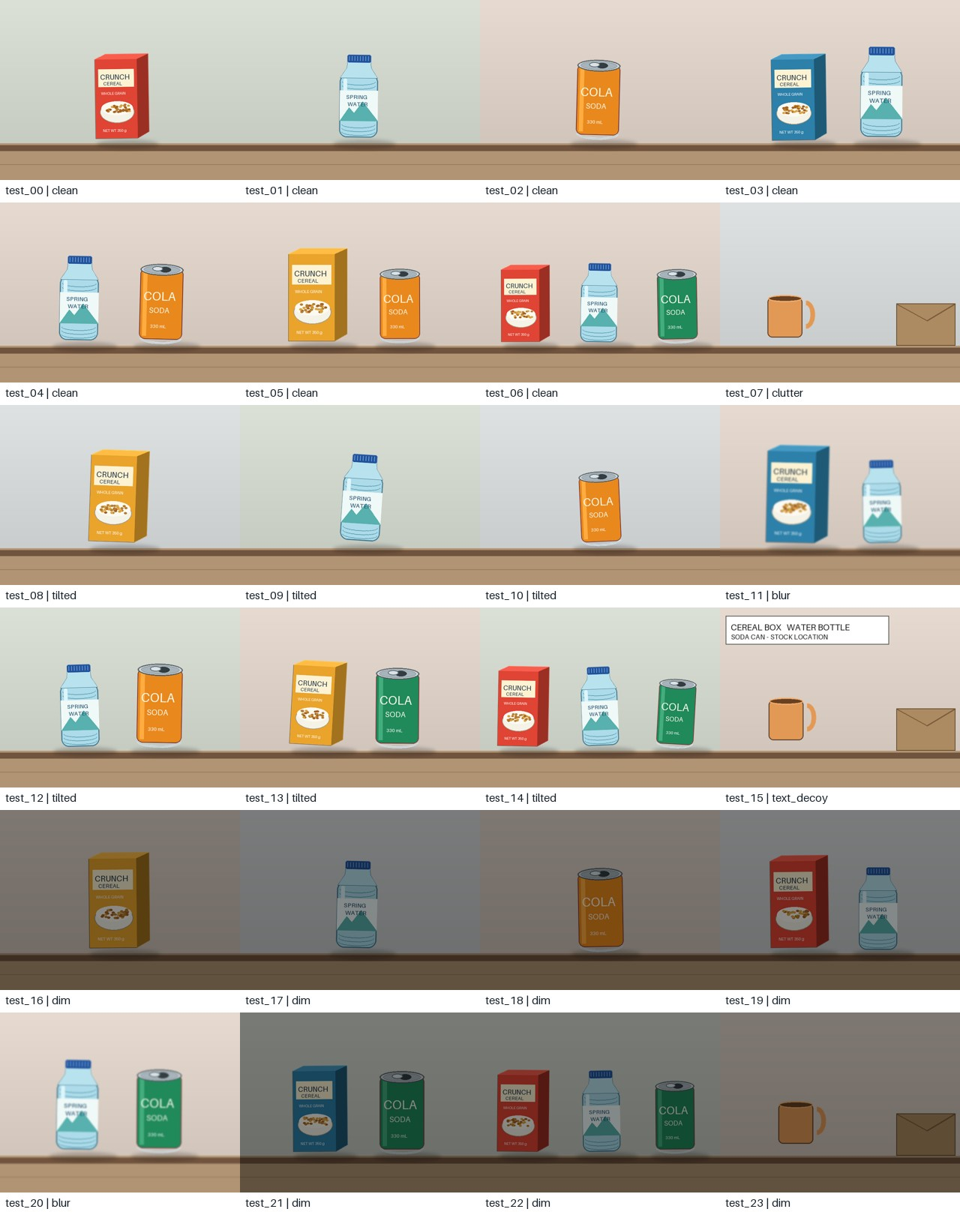

In [3]:
from pathlib import Path
import json, hashlib
import pandas as pd
from PIL import Image as PILImage
from IPython.display import display, Markdown
from retail_demo import make_dataset, RetailPipeline, overlay, evaluate, PROMPTS, CONFIG
DATA = Path("data")
records = make_dataset(DATA)
print(pd.Series([r["split"] for r in records]).value_counts().to_string())
print("Frozen prompts:", PROMPTS)
print("Thresholds:", CONFIG)
assert len({r["image_sha256"] for r in records}) == 36
assert len([r for r in records if r["split"] == "test"]) == 24
display(PILImage.open(DATA / "test_contact_sheet.jpg").resize((960,1215)))

## 4. Load the frozen pipeline
The first run downloads the weights. Subsequent prompts reuse the models. CLIP accepts a crop only when its prompt cosine is at least 0.20 and its margin over fixed background controls is at least 0.02. This screen helps compare semantics but is not a defect certificate.

A DINO score is not a probability of correctness. A CLIP cosine is not a confidence percentage. SAM's predicted mask quality is not proof that the requested object or defect exists.

In [4]:
pipe = RetailPipeline()
print("Models loaded on", pipe.device)

preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Models loaded on cuda


## 5. Live demo - change the prompt and run
Try `water bottle`, `cereal box`, or `soda can` on this scene. You can also set `IMAGE_PATH` to your own uploaded image and enter a different product description. Open vocabulary means flexible text input, not guaranteed accuracy on every description.

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

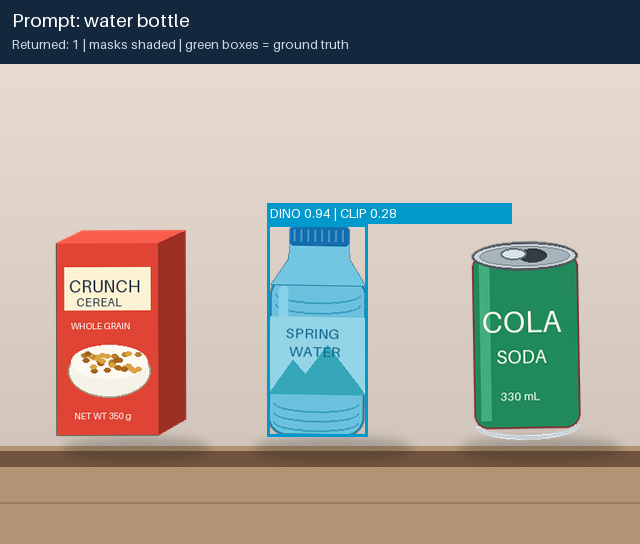

,box,dino_score,dino_phrase,clip_cosine,clip_margin,accepted,sam_predicted_iou
0,"[267.04840087890625, 160.599853515625, 367.472...",0.942729,water bottle,0.280026,0.07183,True,0.999781


Actual inference time: 6.67 s


In [5]:
IMAGE_PATH = DATA / "images/test_06.png"
PROMPT = "water bottle"  # edit this string and rerun this cell
live_image = PILImage.open(IMAGE_PATH).convert("RGB")
live_result = pipe.predict(live_image, PROMPT)
display(overlay(live_image, live_result))
display(pd.DataFrame([{k:v for k,v in p.items() if k != "mask"} for p in live_result["predictions"]]))
print(f"Actual inference time: {live_result['latency_s']:.2f} s")

## 6. Same image, different wording
Run a fixed paraphrase with identical model settings. A similar result on this one image does not mean all prompts are interchangeable; inspect the full paired table below.

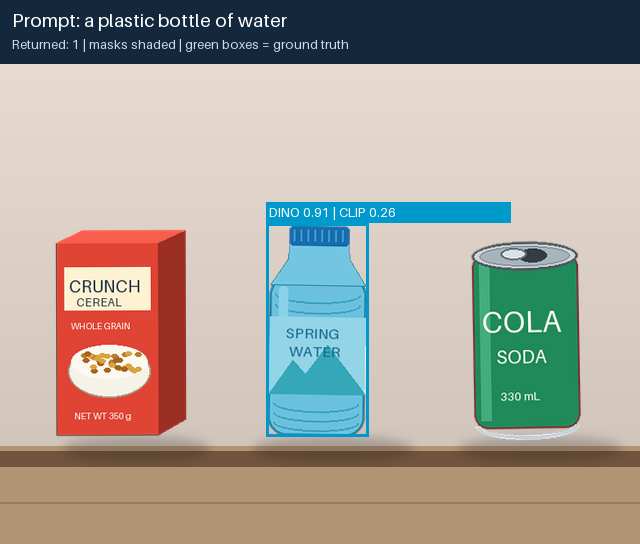

In [6]:
paired_result = pipe.predict(live_image, "a plastic bottle of water")
display(overlay(live_image, paired_result))

## 7. Reproduce a measured false positive
First inspect what is actually present. Then run the prompt and compare it with the annotations. This case was selected **after evaluation to illustrate a failure**, not to estimate its prevalence. It is excluded from main held-out metrics when its split is `stress`.

If a different device or software stack changes the output, describe what you observe; do not claim a failure that the new run did not produce. The measured CPU evidence is preserved in the report and complete ZIP.

Recorded prompt: damaged cereal box
Annotated targets for this query: 0


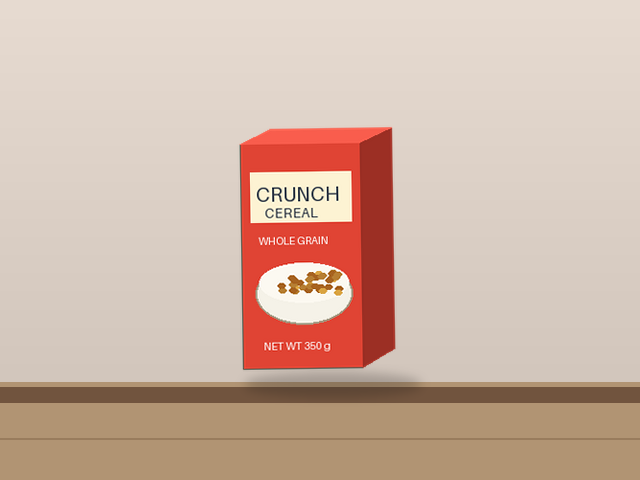

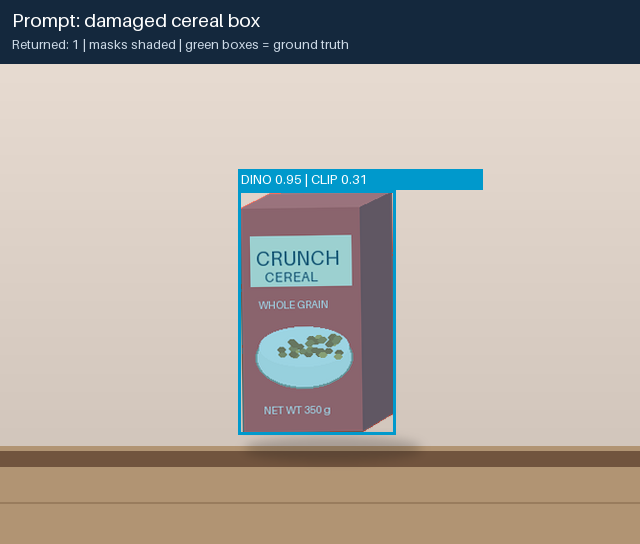

,box,dino_score,dino_phrase,clip_cosine,clip_margin,accepted,sam_predicted_iou
0,"[238.836669921875, 126.28056335449219, 395.897...",0.953671,cereal box,0.305803,0.088274,True,1.005237


Observed failure reproduced: True
Plausible explanation: noun recognition can dominate defect-attribute verification; SAM follows the box.


In [7]:
RECORDED_FAILURE = {'trial_id': 'stress_00__defect_stress__stress', 'image_id': 'stress_00', 'split': 'stress', 'prompt': 'damaged cereal box', 'kind': 'absent_target_false_positive', 'dino_score': 0.9536552429199219, 'clip_cosine': 0.30580294132232666, 'clip_margin': 0.08827431499958038, 'confident_by_preregistered_rule': True, 'n_gt': 0, 'n_predictions': 1, 'box': [238.8368377685547, 126.2806625366211, 395.8976745605469, 370.1781311035156], 'overlay': 'trials/stress_00__defect_stress__stress/overlay.jpg', 'reproduce': 'python retail_demo.py --image data/images/stress_00.png --prompt "damaged cereal box" --output reproduced'}
failure_record = next(r for r in records if r["id"] == RECORDED_FAILURE["image_id"])
failure_image = PILImage.open(DATA / failure_record["image"]).convert("RGB")
print("Recorded prompt:", RECORDED_FAILURE["prompt"])
print("Annotated targets for this query:", RECORDED_FAILURE["n_gt"])
display(failure_image)
failure_result = pipe.predict(failure_image, RECORDED_FAILURE["prompt"])
display(overlay(failure_image, failure_result, gt=[]))
display(pd.DataFrame([{k:v for k,v in p.items() if k != "mask"} for p in failure_result["predictions"]]))
print("Observed failure reproduced:", len(failure_result["predictions"]) > 0)
print("Plausible explanation: noun recognition can dominate defect-attribute verification; SAM follows the box.")

## 8. Recorded completed CPU evaluation
These are the saved results from the completed 144-query test plus 6 stress queries. They are **not recomputed by displaying this cell**. The matching is one-to-one at box IoU >= 0.50. Main tables exclude the stress set. Raw scores, masks, overlays, environment, and reproduction evidence are in the complete project ZIP.

In [8]:
RECORDED_REPORT = '# Week 04 — RetailEdge evaluation results\n\nStatus: measured model inference, not simulated scores. All models are frozen; no fine-tuning or task-specific training.\n\n## Evaluation protocol\n\n24 synthetic held-out images, 3 categories, 2 predeclared prompt variants: 144 image-query trials. Each category has 12 positive and 12 negative images per wording. There are 36 product instances; each is queried once per wording. Six development scenes are excluded, and six separate defect/decoy stress scenes are reported separately. These are procedural illustrations, not warehouse photographs. Held-out means withheld from our setup decisions; pretraining membership cannot be audited.\n\nOne-to-one matching at box IoU >= 0.50. Precision = TP/(TP+FP); recall = TP/(TP+FN); F1 = 2TP/(2TP+FP+FN). Exact-query accuracy requires every target found and zero extra boxes, so empty queries only count as correct when no box is returned. Mask IoU is measured against generated foreground masks on box true positives. Mask success/GT includes missed objects as failures. Undefined ratios are N/A.\n\n## Written evaluation results table\n\n| Category | Wording | TP / FP / FN | Precision | Recall | F1 | Exact-query accuracy | Mask IoU (box TP only) | Production readiness assessment |\n|---|---|---|---|---|---|---|---|---|\n| cereal box | canonical | 12 / 0 / 0 | 100.0% | 100.0% | 100.0% | 100.0% | 98.0% | POC only: 0 false positives and 0 misses in 24 synthetic queries; real-camera and defect validation required. |\n| cereal box | paraphrase | 12 / 0 / 0 | 100.0% | 100.0% | 100.0% | 100.0% | 98.0% | POC only: 0 false positives and 0 misses in 24 synthetic queries; real-camera and defect validation required. |\n| water bottle | canonical | 12 / 1 / 0 | 92.3% | 100.0% | 96.0% | 95.8% | 98.6% | POC only: 1 false positives and 0 misses in 24 synthetic queries; real-camera and defect validation required. |\n| water bottle | paraphrase | 12 / 0 / 0 | 100.0% | 100.0% | 100.0% | 100.0% | 98.7% | POC only: 0 false positives and 0 misses in 24 synthetic queries; real-camera and defect validation required. |\n| soda can | canonical | 12 / 10 / 0 | 54.5% | 100.0% | 70.6% | 58.3% | 95.6% | POC only: 10 false positives and 0 misses in 24 synthetic queries; real-camera and defect validation required. |\n| soda can | paraphrase | 12 / 1 / 0 | 92.3% | 100.0% | 96.0% | 95.8% | 95.7% | POC only: 1 false positives and 0 misses in 24 synthetic queries; real-camera and defect validation required. |\n\n| Overall wording | Precision | Recall | F1 | Exact-query accuracy | Negative-query FP rate | Mask success/GT | Mean workflow seconds/query |\n|---|---|---|---|---|---|---|---|\n| canonical | 76.6% | 100.0% | 86.7% | 84.7% | 13.9% (5/36) | 100.0% | 4.06 |\n| paraphrase | 97.3% | 100.0% | 98.6% | 98.6% | 2.8% (1/36) | 100.0% | 2.29 |\n\nTiming includes preprocessing, CLIP, and SAM when used, excludes model download/load and file export. SAM image embeddings and CLIP text features are reused across queries. Query order is fixed, so timings by wording are affected by cache order; they are not independent cold-start latency measurements.\n\n## Prompt sensitivity — paired images, unchanged thresholds\n\n| Category | Canonical prompt | Paraphrase | F1 difference (paraphrase minus canonical) |\n|---|---|---|---|\n| cereal_box | cereal box | a cardboard box of cereal | +0.0 percentage points |\n| water_bottle | water bottle | a plastic bottle of water | +4.0 percentage points |\n| soda_can | soda can | an aluminum can of soda | +25.4 percentage points |\n\nNo best prompt is selected after seeing test results. The 144 queries share 24 scenes and are not 144 independent images. Small sample size, correlated synthetic designs, and synthetic-to-real shift limit generalization.\n\n## Hallucination / confident false-positive evidence\n\n| Image | Prompt | Ground-truth targets | Returned boxes | DINO score | CLIP cosine / margin | Finding | Production implication |\n|---|---|---|---|---|---|---|---|\n| stress_00 (stress) | damaged cereal box | 0 | 1 | 0.954 | 0.306 / 0.088 | Genuine absent-target FP; high-score criterion met: True | Require human confirmation; a returned mask does not establish defect presence. |\n| stress_05 (stress) | damaged soda can | 0 | 1 | 0.915 | 0.265 / 0.038 | Genuine absent-target FP; high-score criterion met: True | Require human confirmation; a returned mask does not establish defect presence. |\n| stress_02 (stress) | bottle with a misaligned label | 0 | 1 | 0.836 | 0.257 / 0.052 | Genuine absent-target FP; high-score criterion met: True | Require human confirmation; a returned mask does not establish defect presence. |\n| test_17 (test) | soda can | 0 | 1 | 0.942 | 0.238 / 0.024 | Genuine absent-target FP; high-score criterion met: True | Require human confirmation; a returned mask does not establish defect presence. |\n\nHigh-score criterion was DINO >= 0.50 after the CLIP gate. DINO scores, CLIP cosine/margins, and SAM predicted IoU are model scores, not calibrated probabilities. Full evidence and exact reproduction commands are in failure_cases.csv and selected_failure.json. The cited cases are selected failure examples, not estimates of prevalence. Stress cases never enter the held-out accuracy table.\n\n## Why it works — and why it fails\n\nCLIP contrastive pretraining aligns paired images and text in a shared embedding space while separating mismatched pairs. Here CLIP scores detector crops; ordinary CLIP does not directly produce bounding boxes. Grounding DINO supplies region–text grounding and candidate boxes. SAM receives those boxes and predicts masks; it does not independently verify the requested category or defect.\n\nChanging wording changes text tokens, text embeddings, and the detector’s text-conditioned regions. CLIP also sees a different embedding for the crop comparison. A strong match to a noun such as box or bottle can outweigh a subtle attribute such as damaged or misaligned. Comparing a product crop with empty-shelf controls is insufficient to certify the defect. SAM can still trace a convincing object mask after the semantic decision is wrong. This mechanism is a plausible interpretation of the observed outputs, not a causal attribution proved by this small experiment.\n\n## Production decision for Priya\n\nNo-go for autonomous product acceptance/rejection. Suitable for a supervised feasibility demonstration only. The measured table quantifies errors and wording sensitivity on synthetic scenes, not factory performance. Before a pilot, collect independently annotated real shelf images across SKUs, cameras, lighting, occlusion and defect types; retain a sealed test set; tune thresholds only on a separate development set; calibrate abstention; test normal/defective contrast prompts; validate mask boundaries and small defects; and measure uncached deployment latency on the target hardware. No universal production accuracy target is assumed—Priya and quality stakeholders must define the cost of misses and false rejects.\n\n## Primary references\n\n- Radford et al. (2021), Learning Transferable Visual Models From Natural Language Supervision: https://proceedings.mlr.press/v139/radford21a.html\n- Liu et al., Grounding DINO: https://arxiv.org/abs/2303.05499\n- Kirillov et al. (2023), Segment Anything: https://arxiv.org/abs/2304.02643\n- Grounded SAM reference composition: https://github.com/IDEA-Research/Grounded-Segment-Anything\n- Pinned API documentation: https://huggingface.co/docs/transformers/v4.51.3/model_doc/grounding-dino and https://huggingface.co/docs/transformers/v4.51.3/model_doc/sam\n\nReproducibility: frozen settings, exact model revisions, dataset hashes, software versions, per-query evidence and masks accompany this report. No image-generation service, external stock image, or proprietary training data is required.\n'
display(Markdown(RECORDED_REPORT))

# Week 04 — RetailEdge evaluation results

Status: measured model inference, not simulated scores. All models are frozen; no fine-tuning or task-specific training.

## Evaluation protocol

24 synthetic held-out images, 3 categories, 2 predeclared prompt variants: 144 image-query trials. Each category has 12 positive and 12 negative images per wording. There are 36 product instances; each is queried once per wording. Six development scenes are excluded, and six separate defect/decoy stress scenes are reported separately. These are procedural illustrations, not warehouse photographs. Held-out means withheld from our setup decisions; pretraining membership cannot be audited.

One-to-one matching at box IoU >= 0.50. Precision = TP/(TP+FP); recall = TP/(TP+FN); F1 = 2TP/(2TP+FP+FN). Exact-query accuracy requires every target found and zero extra boxes, so empty queries only count as correct when no box is returned. Mask IoU is measured against generated foreground masks on box true positives. Mask success/GT includes missed objects as failures. Undefined ratios are N/A.

## Written evaluation results table

| Category | Wording | TP / FP / FN | Precision | Recall | F1 | Exact-query accuracy | Mask IoU (box TP only) | Production readiness assessment |
|---|---|---|---|---|---|---|---|---|
| cereal box | canonical | 12 / 0 / 0 | 100.0% | 100.0% | 100.0% | 100.0% | 98.0% | POC only: 0 false positives and 0 misses in 24 synthetic queries; real-camera and defect validation required. |
| cereal box | paraphrase | 12 / 0 / 0 | 100.0% | 100.0% | 100.0% | 100.0% | 98.0% | POC only: 0 false positives and 0 misses in 24 synthetic queries; real-camera and defect validation required. |
| water bottle | canonical | 12 / 1 / 0 | 92.3% | 100.0% | 96.0% | 95.8% | 98.6% | POC only: 1 false positives and 0 misses in 24 synthetic queries; real-camera and defect validation required. |
| water bottle | paraphrase | 12 / 0 / 0 | 100.0% | 100.0% | 100.0% | 100.0% | 98.7% | POC only: 0 false positives and 0 misses in 24 synthetic queries; real-camera and defect validation required. |
| soda can | canonical | 12 / 10 / 0 | 54.5% | 100.0% | 70.6% | 58.3% | 95.6% | POC only: 10 false positives and 0 misses in 24 synthetic queries; real-camera and defect validation required. |
| soda can | paraphrase | 12 / 1 / 0 | 92.3% | 100.0% | 96.0% | 95.8% | 95.7% | POC only: 1 false positives and 0 misses in 24 synthetic queries; real-camera and defect validation required. |

| Overall wording | Precision | Recall | F1 | Exact-query accuracy | Negative-query FP rate | Mask success/GT | Mean workflow seconds/query |
|---|---|---|---|---|---|---|---|
| canonical | 76.6% | 100.0% | 86.7% | 84.7% | 13.9% (5/36) | 100.0% | 4.06 |
| paraphrase | 97.3% | 100.0% | 98.6% | 98.6% | 2.8% (1/36) | 100.0% | 2.29 |

Timing includes preprocessing, CLIP, and SAM when used, excludes model download/load and file export. SAM image embeddings and CLIP text features are reused across queries. Query order is fixed, so timings by wording are affected by cache order; they are not independent cold-start latency measurements.

## Prompt sensitivity — paired images, unchanged thresholds

| Category | Canonical prompt | Paraphrase | F1 difference (paraphrase minus canonical) |
|---|---|---|---|
| cereal_box | cereal box | a cardboard box of cereal | +0.0 percentage points |
| water_bottle | water bottle | a plastic bottle of water | +4.0 percentage points |
| soda_can | soda can | an aluminum can of soda | +25.4 percentage points |

No best prompt is selected after seeing test results. The 144 queries share 24 scenes and are not 144 independent images. Small sample size, correlated synthetic designs, and synthetic-to-real shift limit generalization.

## Hallucination / confident false-positive evidence

| Image | Prompt | Ground-truth targets | Returned boxes | DINO score | CLIP cosine / margin | Finding | Production implication |
|---|---|---|---|---|---|---|---|
| stress_00 (stress) | damaged cereal box | 0 | 1 | 0.954 | 0.306 / 0.088 | Genuine absent-target FP; high-score criterion met: True | Require human confirmation; a returned mask does not establish defect presence. |
| stress_05 (stress) | damaged soda can | 0 | 1 | 0.915 | 0.265 / 0.038 | Genuine absent-target FP; high-score criterion met: True | Require human confirmation; a returned mask does not establish defect presence. |
| stress_02 (stress) | bottle with a misaligned label | 0 | 1 | 0.836 | 0.257 / 0.052 | Genuine absent-target FP; high-score criterion met: True | Require human confirmation; a returned mask does not establish defect presence. |
| test_17 (test) | soda can | 0 | 1 | 0.942 | 0.238 / 0.024 | Genuine absent-target FP; high-score criterion met: True | Require human confirmation; a returned mask does not establish defect presence. |

High-score criterion was DINO >= 0.50 after the CLIP gate. DINO scores, CLIP cosine/margins, and SAM predicted IoU are model scores, not calibrated probabilities. Full evidence and exact reproduction commands are in failure_cases.csv and selected_failure.json. The cited cases are selected failure examples, not estimates of prevalence. Stress cases never enter the held-out accuracy table.

## Why it works — and why it fails

CLIP contrastive pretraining aligns paired images and text in a shared embedding space while separating mismatched pairs. Here CLIP scores detector crops; ordinary CLIP does not directly produce bounding boxes. Grounding DINO supplies region–text grounding and candidate boxes. SAM receives those boxes and predicts masks; it does not independently verify the requested category or defect.

Changing wording changes text tokens, text embeddings, and the detector’s text-conditioned regions. CLIP also sees a different embedding for the crop comparison. A strong match to a noun such as box or bottle can outweigh a subtle attribute such as damaged or misaligned. Comparing a product crop with empty-shelf controls is insufficient to certify the defect. SAM can still trace a convincing object mask after the semantic decision is wrong. This mechanism is a plausible interpretation of the observed outputs, not a causal attribution proved by this small experiment.

## Production decision for Priya

No-go for autonomous product acceptance/rejection. Suitable for a supervised feasibility demonstration only. The measured table quantifies errors and wording sensitivity on synthetic scenes, not factory performance. Before a pilot, collect independently annotated real shelf images across SKUs, cameras, lighting, occlusion and defect types; retain a sealed test set; tune thresholds only on a separate development set; calibrate abstention; test normal/defective contrast prompts; validate mask boundaries and small defects; and measure uncached deployment latency on the target hardware. No universal production accuracy target is assumed—Priya and quality stakeholders must define the cost of misses and false rejects.

## Primary references

- Radford et al. (2021), Learning Transferable Visual Models From Natural Language Supervision: https://proceedings.mlr.press/v139/radford21a.html
- Liu et al., Grounding DINO: https://arxiv.org/abs/2303.05499
- Kirillov et al. (2023), Segment Anything: https://arxiv.org/abs/2304.02643
- Grounded SAM reference composition: https://github.com/IDEA-Research/Grounded-Segment-Anything
- Pinned API documentation: https://huggingface.co/docs/transformers/v4.51.3/model_doc/grounding-dino and https://huggingface.co/docs/transformers/v4.51.3/model_doc/sam

Reproducibility: frozen settings, exact model revisions, dataset hashes, software versions, per-query evidence and masks accompany this report. No image-generation service, external stock image, or proprietary training data is required.


## 9. Optional full rerun
Set the flag to `True` to evaluate all 24 test scenes under both wordings, plus the separate stress scenes. CPU takes several minutes. The outputs go to `rerun_outputs`, preserving the recorded report above. If you change prompts or thresholds after seeing test results, label it as an exploratory experiment and obtain a new held-out test set for an unbiased final estimate.

In [9]:
RUN_FULL_EVALUATION = False  # True performs a fresh full model evaluation
if RUN_FULL_EVALUATION:
    new_summary, new_overall = evaluate(pipe, DATA, "rerun_outputs")
    display(Markdown(Path("rerun_outputs/Evaluation_Results.md").read_text()))
else:
    print("Full rerun skipped. Section 8 shows the completed recorded CPU evaluation.")

Full rerun skipped. Section 8 shows the completed recorded CPU evaluation.


## 10. Download a fresh run, when requested
The original complete project ZIP already contains the completed evaluation. This cell packages the module, data, and outputs from a new run, if you performed one.

In [10]:
if RUN_FULL_EVALUATION:
    import zipfile
    package = Path("Week04_RetailEdge_Rerun.zip")
    with zipfile.ZipFile(package, "w", zipfile.ZIP_DEFLATED) as z:
        z.write("retail_demo.py")
        for folder in [Path("data"), Path("rerun_outputs")]:
            for f in folder.rglob("*"):
                if f.is_file(): z.write(f)
    try:
        from google.colab import files
        files.download(str(package))
    except ImportError:
        print("Saved:", package.resolve())